# Análise dos dados municipais de saneamento — IBGE/SIDRA

Este notebook analisa as fontes de saneamento antes de qualquer integração com o SINAN. O recorte é nacional e municipal.

## Fontes e recortes temporais

- **Tabela 3218 (2010):** água, banheiro/esgotamento, lixo e energia elétrica.
- **Tabelas 6803, 6805 e 6892 (2022):** água, esgotamento e lixo no Censo 2022.
- **Tabela 6579:** estimativas populacionais nos anos disponíveis entre 2001 e 2021.
- **Tabela 4709:** população residente do Censo 2022.

A antiga tabela 1027 foi removida: ela descreve a execução do manejo de águas pluviais em 2008 e não representa diretamente as condições domiciliares de saneamento.

In [1]:
import polars as pl
import plotly.express as px

from analysis_pipeline import build_ibge_outputs

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(12)

polars.config.Config

## Carregamento reproduzível

Na primeira execução, as consultas são feitas na API SIDRA. Nas seguintes, os Parquets validados em `sinan/processados/` são reutilizados. Use `refresh=True` somente quando quiser atualizar a extração.

In [2]:
ibge = build_ibge_outputs(refresh=False)

populacao = ibge['populacao']
saneamento_2010 = ibge['saneamento_2010']
saneamento_2010_longo = ibge['saneamento_2010_longo']
saneamento_2022 = ibge['saneamento_2022']
saneamento_2022_longo = ibge['saneamento_2022_longo']

pl.DataFrame({
    'base': ['população', 'saneamento 2010', 'saneamento 2022'],
    'linhas': [populacao.height, saneamento_2010.height, saneamento_2022.height],
    'municipios': [populacao['codigo_municipio'].n_unique(), saneamento_2010.height, saneamento_2022.height],
})

base,linhas,municipios
str,i64,i64
"""população""",111419,5571
"""saneamento 2010""",5565,5565
"""saneamento 2022""",5570,5570


## Qualidade e completude

As consultas mantêm somente categorias elementares. Categorias-pai como “Coletado” não são somadas novamente com seus subtipos. Cada dimensão deve totalizar aproximadamente 100%, permitindo apenas diferenças de arredondamento.

In [3]:
def auditar_percentuais(df_longo: pl.DataFrame) -> pl.DataFrame:
    return (
        df_longo
        .group_by('codigo_municipio', 'dimensao')
        .agg(pl.col('valor').sum().alias('soma_percentuais'))
        .group_by('dimensao')
        .agg(
            pl.len().alias('municipios'),
            pl.col('soma_percentuais').min().alias('minimo'),
            pl.col('soma_percentuais').median().alias('mediana'),
            pl.col('soma_percentuais').max().alias('maximo'),
            ((pl.col('soma_percentuais') - 100).abs() > 0.2).sum().alias('fora_tolerancia'),
        )
        .sort('dimensao')
    )

print('Censo 2010')
display(auditar_percentuais(saneamento_2010_longo))
print('Censo 2022')
display(auditar_percentuais(saneamento_2022_longo))

Censo 2010


dimensao,municipios,minimo,mediana,maximo,fora_tolerancia
str,u32,f64,f64,f64,u32
"""agua""",5565,99.98,100.0,100.02,0
"""energia""",5565,100.0,100.0,100.01,0
"""esgotamento""",5565,99.98,100.0,100.02,0
"""lixo""",5565,99.99,100.0,100.01,0


Censo 2022


dimensao,municipios,minimo,mediana,maximo,fora_tolerancia
str,u32,f64,f64,f64,u32
"""agua""",5570,99.96,100.0,100.04,0
"""esgotamento""",5570,99.97,100.0,100.02,0
"""lixo""",5570,99.98,100.0,100.02,0


## Análise exploratória — Censo 2010

In [4]:
indicadores_2010 = [
    'pct_agua_rede_geral',
    'pct_banheiro_exclusivo_rede_ou_fossa_septica',
    'pct_sem_banheiro_ou_sanitario',
    'pct_lixo_outro_destino',
    'pct_sem_energia_eletrica',
]
saneamento_2010.select(indicadores_2010).describe(percentiles=[0.25, 0.5, 0.75])

statistic,pct_agua_rede_geral,pct_banheiro_exclusivo_rede_ou_fossa_septica,pct_sem_banheiro_ou_sanitario,pct_lixo_outro_destino,pct_sem_energia_eletrica
str,f64,f64,f64,f64,f64
"""count""",5565.0,5565.0,5565.0,5565.0,5565.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",69.095242,41.746422,6.15214,29.743423,2.956031
"""std""",19.933278,31.258074,9.930181,21.846971,5.799499
"""min""",0.0,0.0,0.0,0.0,0.0
"""25%""",57.54,12.08,0.23,10.77,0.24
"""50%""",72.57,37.37,1.27,25.9,0.83
"""75%""",84.68,69.91,7.99,45.64,2.7
"""max""",99.96,99.88,67.15,100.0,70.78


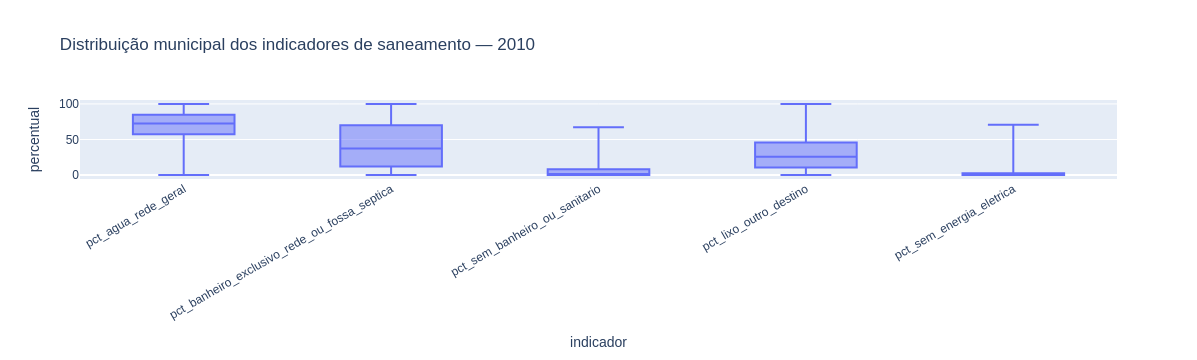

In [5]:
grafico_2010 = saneamento_2010.select(indicadores_2010).unpivot(
    variable_name='indicador', value_name='percentual'
).to_pandas()
px.box(
    grafico_2010, x='indicador', y='percentual', points=False,
    title='Distribuição municipal dos indicadores de saneamento — 2010',
).update_layout(xaxis_tickangle=-30)

## Análise exploratória — Censo 2022

In [6]:
indicadores_2022 = [
    'pct_agua_rede_geral_principal',
    'pct_esgoto_rede_geral_ou_pluvial',
    'pct_esgoto_fossa_nao_ligada_rede',
    'pct_sem_banheiro_ou_sanitario',
    'pct_lixo_queimado_propriedade',
    'pct_lixo_terreno_encosta_area_publica',
]
saneamento_2022.select(indicadores_2022).describe(percentiles=[0.25, 0.5, 0.75])

statistic,pct_agua_rede_geral_principal,pct_esgoto_rede_geral_ou_pluvial,pct_esgoto_fossa_nao_ligada_rede,pct_sem_banheiro_ou_sanitario,pct_lixo_queimado_propriedade,pct_lixo_terreno_encosta_area_publica
str,f64,f64,f64,f64,f64,f64
"""count""",5570.0,5570.0,5570.0,5570.0,5570.0,5570.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",71.722452,34.273984,17.334014,1.233801,17.619973,0.738526
"""std""",19.595804,32.848113,19.466093,3.232158,16.230965,1.43579
"""min""",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",60.66,1.96,3.3,0.0,4.12,0.03
"""50%""",75.79,25.92,10.44,0.08,12.75,0.21
"""75%""",86.96,63.36,23.62,0.88,27.57,0.86
"""max""",100.0,99.83,98.99,39.73,85.25,30.17


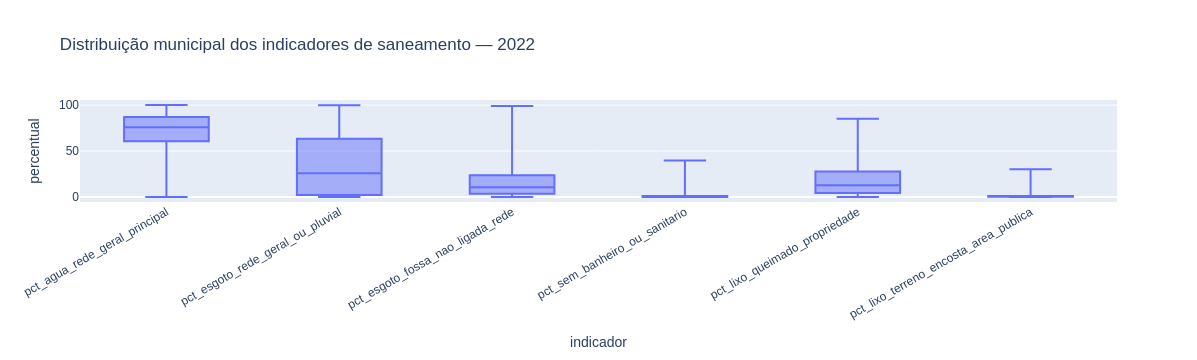

In [7]:
grafico_2022 = saneamento_2022.select(indicadores_2022).unpivot(
    variable_name='indicador', value_name='percentual'
).to_pandas()
px.box(
    grafico_2022, x='indicador', y='percentual', points=False,
    title='Distribuição municipal dos indicadores de saneamento — 2022',
).update_layout(xaxis_tickangle=-30)

## População disponível para taxas

In [8]:
(
    populacao
    .group_by('ano', 'fonte_populacao')
    .agg(
        pl.len().alias('municipios'),
        pl.col('populacao').sum().alias('populacao_total'),
    )
    .sort('ano')
)

ano,fonte_populacao,municipios,populacao_total
i32,str,u32,u64
2001,"""SIDRA 6579 - estimativa popula…",5571,172385826
2002,"""SIDRA 6579 - estimativa popula…",5571,174632960
2003,"""SIDRA 6579 - estimativa popula…",5571,176871437
2004,"""SIDRA 6579 - estimativa popula…",5571,181581024
2005,"""SIDRA 6579 - estimativa popula…",5571,184184264
2006,"""SIDRA 6579 - estimativa popula…",5571,186770562
…,…,…,…
2017,"""SIDRA 6579 - estimativa popula…",5571,207660929
2018,"""SIDRA 6579 - estimativa popula…",5571,208494900


## Conclusões da fonte

- As bases cobrem todos os municípios existentes em cada Censo: 5.565 em 2010 e 5.570 em 2022.
- Os percentuais foram construídos com categorias mutuamente exclusivas e fecham em 100% dentro da tolerância de arredondamento.
- Os dados representam condições domiciliares agregadas; não descrevem a exposição individual de cada pessoa notificada.
- As comparações temporais devem considerar mudanças de categorias e da malha municipal entre os Censos.